# Perfil de Temperatura en la Zona Radiativa Solar
### 

**Curso:** Astrofísica Computacional  
**Autor:** Andres Felipe Suarez Reyes  
**Fecha:** 24/04/2026

## 1. Planteamiento del problema

Se desea modelar el perfil de temperatura $T(r)$ en la zona radiativa del Sol resolviendo la ecuación diferencial:

$$
\frac{d^2 T}{dr^2} + \frac{2}{r}\frac{dT}{dr} = 0
$$

Se asume:

- No existen fuentes internas.
- La conducción es perfecta.
## 2. Condiciones de frontera

Se imponen las siguientes condiciones:

$$
T(0.25 R_\odot) = 4 \times 10^6 \, K
$$

$$
T(R_\odot) = 5778 \, K
$$

donde $R_\odot$ es el radio del Sol.
## 3. Solución exacta

La ecuación diferencial tiene como solución general:

$$
T(r) = A + \frac{B}{r}
$$

Las constantes $A$ y $B$ se determinan usando las condiciones de frontera.

Esta solución se utilizará para calcular el error del método numérico.

## 4. Solucion numerica

$$
\frac{T_{i+1} - 2T_i + T_{i-1}}{\Delta r^2}
+ \frac{1}{r_i \Delta r}(T_{i+1} - T_{i-1}) = 0
$$



In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
R = 1.0  # puedes normalizar R☉ = 1
r1 = 0.25 * R
r2 = R

T1 = 4e6
T2 = 5778

def solve_fd(N):
    r = np.linspace(r1, r2, N)
    dr = r[1] - r[0]

    A = np.zeros((N, N))
    b = np.zeros(N)

    # Condiciones de frontera
    A[0, 0] = 1 # T_0 = T1
    b[0] = T1

    A[-1, -1] = 1 # T_{N-1} = T2
    b[-1] = T2

    # Ecuaciones internas
    for i in range(1, N-1):
        ri = r[i]

        A[i, i-1] = 1/dr**2 - 1/(ri*dr) # T_{i-1} coeficiente \delta r^{-2} - \frac{1}{r_i \delta r} ver ecuación de diferencias finitas
        A[i, i]   = -2/dr**2            # T_i coeficiente -2 \delta r^{-2} ver ecuación de diferencias finitas
        A[i, i+1] = 1/dr**2 + 1/(ri*dr) # T_{i+1} coeficiente \delta r^{-2} + \frac{1}{r_i \delta r} ver ecuación de diferencias finitas

    T = np.linalg.solve(A, b)

    return r, T

In [19]:
def exact_solution(r):
    # Resolver constantes A y B
    r1 = 0.25
    r2 = 1.0
    T1 = 4e6
    T2 = 5778

    # Sistema:
    # A + B/r1 = T1
    # A + B/r2 = T2

    B = (T1 - T2) / (1/r1 - 1/r2)
    A = T1 - B/r1

    return A + B/r

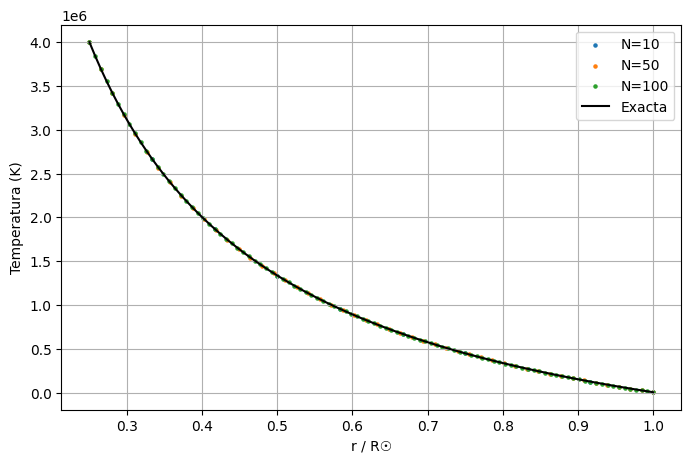

In [31]:
Ns = [10, 50, 100]

plt.figure(figsize=(8,5))

for N in Ns:
    r, T_num = solve_fd(N)
    plt.scatter(r, T_num, label=f"N={N}", s=5)

# Solución exacta
r_fine = np.linspace(0.25, 1.0, 200)
T_exact = exact_solution(r_fine)

plt.plot(r_fine, T_exact, 'k-', label="Exacta")

plt.xlabel("r / R☉")
plt.ylabel("Temperatura (K)")
plt.legend()
plt.grid()
plt.show()

In [28]:
from tabulate import tabulate

Ns = [2,3,4,5,10, 20, 50, 100, 200]

tabla = []

for N in Ns:
    r, T_num = solve_fd(N)
    T_ex = exact_solution(r)
    diferencia = np.max(T_num - T_ex)
    error = 100 * np.max(np.abs((T_num - T_ex)/T_ex)) #toma el valor de error mas grande de la lista
    error_L2 = 100 * np.sqrt(np.mean(((T_num - T_ex)/T_ex)**2)) #como una dispersion de los valores respecto a la solucion exacta.
    tabla.append([N, diferencia, error, error_L2])

print(tabulate(tabla, headers=["N", "Diferencia", "Error relativo %", "Error L2 % "], floatfmt=".3e"))

  N    Diferencia    Error relativo %    Error L2 %
---  ------------  ------------------  -------------
  2     0.000e+00           4.030e-12      2.849e-12
  3    -2.328e-10           4.030e-12      2.327e-12
  4     0.000e+00           4.030e-12      2.015e-12
  5    -2.328e-10           4.030e-12      1.803e-12
 10    -2.328e-10           4.030e-12      1.279e-12
 20    -2.328e-10           4.030e-12      9.363e-13
 50     1.746e-10           4.030e-12      8.210e-13
100    -2.328e-10           5.576e-12      3.283e-12
200     5.495e-08           4.030e-12      2.148e-12


El error para todos los N son del mismo orden y <0.01 % , la solucion numerica para este problema es demasiada exacta  (lo cual se me hace raro).... El error relativo toma el punto de mayor error y el L2 es una dispersion del valor numerico respecto al valor teorico (la magnitud típica del error a lo largo de toda la curva) . psd parece que el error es mas por precision de maquina que por el metodo ya que no depende de N.